# 🔍 Computer Vision — Feature Matching Pipeline
**Pipeline:**  Load → Preprocess → Detect & Extract → FLANN Match → Best Result

Urutan cell:
1. Import
2. Fungsi-fungsi
3. Konfigurasi & Load Data
4. Jalankan Pipeline
5. Tampilkan Hasil

## 1. Import Library

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Fungsi-fungsi Modular

In [2]:
# ─────────────────────────────────────────────
# FUNGSI 1: Preprocessing Image
# BGR → Grayscale → GaussianBlur → equalizeHist
# ─────────────────────────────────────────────
def preprocess(img_bgr):
    """
    Preprocessing gambar: Grayscale + Gaussian Blur + Histogram Equalization.
    Input : gambar BGR (output cv2.imread)
    Output: gambar grayscale yang sudah diproses
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    gray = cv2.equalizeHist(gray)
    return gray

In [3]:
# ─────────────────────────────────────────────
# FUNGSI 2: Inisialisasi Feature Detector
# Pilih: 'SIFT', 'AKAZE', atau 'ORB'
# ─────────────────────────────────────────────
def init_detector(method):
    """
    Membuat objek detector berdasarkan nama metode.
    - SIFT  : akurat, descriptor float (128-dimensi)
    - AKAZE : cepat, descriptor biner
    - ORB   : paling cepat, descriptor biner
    """
    if method == 'SIFT':
        return cv2.SIFT_create()
    elif method == 'AKAZE':
        return cv2.AKAZE_create()
    elif method == 'ORB':
        return cv2.ORB_create()
    else:
        raise ValueError(f"Metode '{method}' tidak dikenal. Pilih: SIFT, AKAZE, ORB")

In [4]:
# ─────────────────────────────────────────────
# FUNGSI 3: Inisialisasi FLANN Matcher
# SIFT  → KD-Tree  (descriptor float)
# AKAZE/ORB → LSH  (descriptor biner)
# ─────────────────────────────────────────────
def init_flann(method):
    """
    Membuat FLANN matcher sesuai tipe descriptor.
    - SIFT  : algorithm=1 (KD-Tree), trees=5
    - ORB/AKAZE: algorithm=6 (LSH)
    checks=50 → jumlah node yang dicek (akurasi vs kecepatan)
    """
    if method == 'SIFT':
        index_params  = dict(algorithm=1, trees=5)   # KD-Tree
    else:
        index_params  = dict(algorithm=6, table_number=6,
                             key_size=12, multi_probe_level=1)  # LSH

    search_params = dict(checks=50)
    return cv2.FlannBasedMatcher(index_params, search_params)

In [5]:
# ─────────────────────────────────────────────
# FUNGSI 4: Feature Matching dengan Lowe's Ratio Test
#
# Lowe's Ratio Test:
#   match dianggap BAIK jika:
#   jarak_match_1 < ratio × jarak_match_2
#   (match pertama jauh lebih dekat → unik & andal)
# ─────────────────────────────────────────────
def match_features(flann, desc_target, desc_source, ratio):
    """
    kNN matching (k=2) + Lowe's Ratio Test.
    Return: (jumlah good matches, matchesMask, raw_matches)
    """
    raw_matches  = flann.knnMatch(desc_target, desc_source, k=2)
    matches_mask = [[0, 0] for _ in range(len(raw_matches))]
    good_count   = 0

    for i, pair in enumerate(raw_matches):
        if len(pair) == 2:
            best, second = pair
            if best.distance < ratio * second.distance:  # Lowe's ratio test
                matches_mask[i] = [1, 0]
                good_count += 1

    return good_count, matches_mask, raw_matches

In [6]:
# ─────────────────────────────────────────────
# FUNGSI 5: Main Pipeline
#   Loop: method → lowe_ratio → tiap source image
#   Cari kombinasi dengan good matches TERBANYAK
# ─────────────────────────────────────────────
def run_pipeline(target_bgr, source_list, methods, lowe_ratios):
    """
    Menjalankan pipeline feature matching.
    Return: dict hasil terbaik (atau None jika tidak ada)
    """
    target_gray = preprocess(target_bgr)   # preprocessing target sekali saja

    best_count  = 0
    best_result = None

    for method in methods:
        print(f"\n[Method: {method}]")

        detector = init_detector(method)
        target_kp, target_desc = detector.detectAndCompute(target_gray, None)

        if target_desc is None:
            print("  ⚠ Deskriptor target tidak ditemukan, skip.")
            continue

        # Konversi tipe sesuai kebutuhan FLANN
        target_desc = np.float32(target_desc) if method == 'SIFT' else np.uint8(target_desc)

        for ratio in lowe_ratios:
            print(f"  Lowe Ratio: {ratio}")
            flann = init_flann(method)

            for item in source_list:
                source_bgr  = item['image']
                source_name = item['name']

                source_gray = preprocess(source_bgr)
                source_kp, source_desc = detector.detectAndCompute(source_gray, None)

                if source_desc is None:
                    print(f"    ⚠ {source_name}: skip (no descriptor)")
                    continue

                source_desc = np.float32(source_desc) if method == 'SIFT' else np.uint8(source_desc)

                good, mask, raw = match_features(flann, target_desc, source_desc, ratio)
                print(f"    {source_name:<22} → {good:>4} good matches")

                if good > best_count:
                    best_count  = good
                    best_result = {
                        'name'       : source_name,
                        'source_bgr' : source_bgr,
                        'source_kp'  : source_kp,
                        'target_kp'  : target_kp,
                        'raw_matches': raw,
                        'mask'       : mask,
                        'good_count' : good,
                        'method'     : method,
                        'ratio'      : ratio,
                    }

    return best_result

## 3. Konfigurasi & Load Data

In [7]:
# ─────────────────────────────────────────────
# Konfigurasi (ubah sesuai kebutuhan)
# ─────────────────────────────────────────────
TARGET_DIR  = 'images/target/'
SOURCE_DIR  = 'images/source/'

METHODS     = ['SIFT', 'AKAZE', 'ORB']   # metode yang dicoba
LOWE_RATIOS = [0.45, 0.50, 0.55]         # nilai ratio yang diuji

# ─────────────────────────────────────────────
# Load Target (ambil file pertama)
# ─────────────────────────────────────────────
target_files = [f for f in sorted(os.listdir(TARGET_DIR)) if not f.startswith('.')]
target_name  = target_files[0]
target_bgr   = cv2.imread(os.path.join(TARGET_DIR, target_name))
print(f"Target: {target_name} | shape: {target_bgr.shape}")

# ─────────────────────────────────────────────
# Load Source Images
# ─────────────────────────────────────────────
source_list = []
for f in sorted(os.listdir(SOURCE_DIR)):
    if f.startswith('.'):
        continue
    img = cv2.imread(os.path.join(SOURCE_DIR, f))
    if img is not None:
        source_list.append({'name': f, 'image': img})

print(f"Jumlah source: {len(source_list)}")

Target: hina.png | shape: (456, 404, 3)
Jumlah source: 12


## 4. Jalankan Pipeline

In [8]:
best = run_pipeline(target_bgr, source_list, METHODS, LOWE_RATIOS)


[Method: SIFT]
  Lowe Ratio: 0.45
    cherino.png            →    1 good matches
    hikari.png             →    1 good matches
    hina.png               →   34 good matches
    hoshino.png            →    2 good matches
    kisaki.png             →    0 good matches
    mika.png               →    1 good matches
    misaki.png             →    2 good matches
    miyako.png             →    0 good matches
    plana.png              →    0 good matches
    shiroko.png            →    0 good matches
    wakamo.png             →    0 good matches
    yuuka.png              →    0 good matches
  Lowe Ratio: 0.5
    cherino.png            →    2 good matches
    hikari.png             →    1 good matches
    hina.png               →   51 good matches
    hoshino.png            →    2 good matches
    kisaki.png             →    0 good matches
    mika.png               →    1 good matches
    misaki.png             →    3 good matches
    miyako.png             →    0 good matches
    pla

## 5. Tampilkan Hasil Terbaik

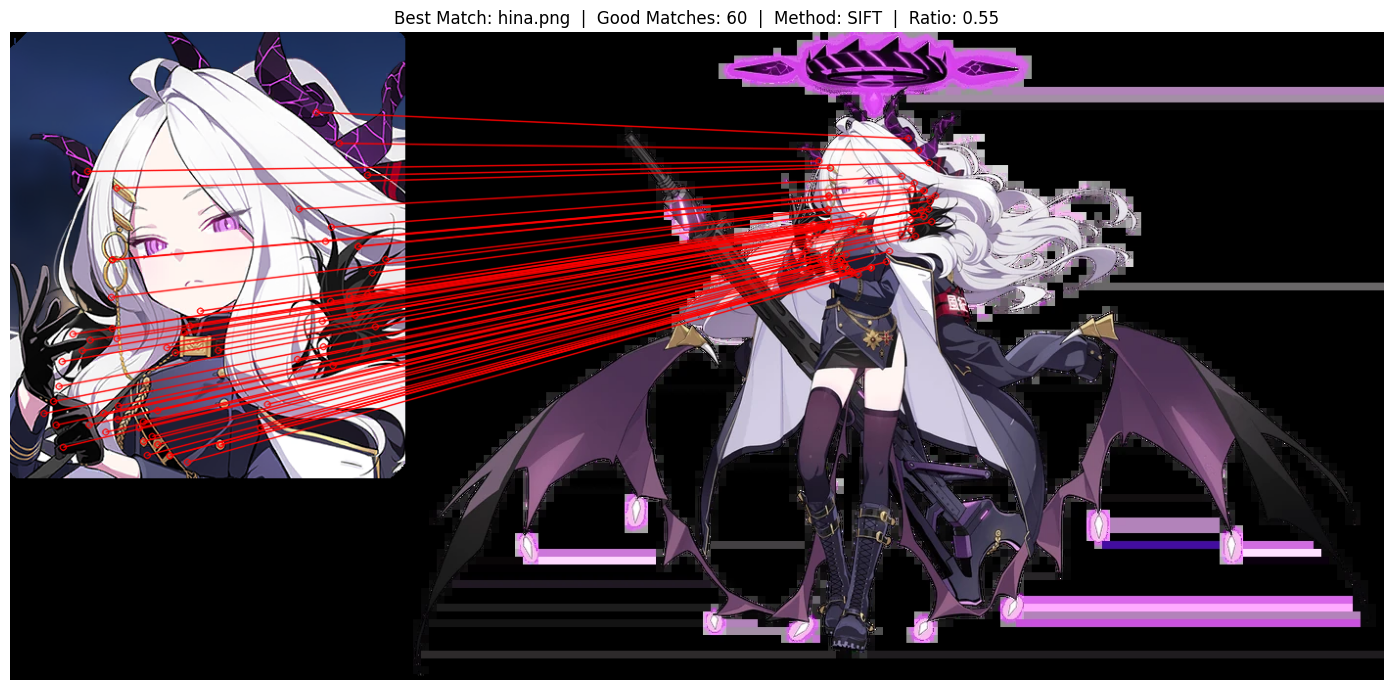


Best Source : hina.png
Method      : SIFT
Lowe Ratio  : 0.55
Good Matches: 60


In [9]:
if best is None:
    print("❌ Tidak ada matching yang berhasil.")
else:
    target_rgb = cv2.cvtColor(target_bgr, cv2.COLOR_BGR2RGB)
    source_rgb = cv2.cvtColor(best['source_bgr'], cv2.COLOR_BGR2RGB)

    result_img = cv2.drawMatchesKnn(
        target_rgb, best['target_kp'],
        source_rgb, best['source_kp'],
        best['raw_matches'],
        None,
        matchesMask  = best['mask'],
        matchColor   = (255, 0, 0),
        flags        = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(18, 7))
    plt.imshow(result_img)
    plt.title(
        f"Best Match: {best['name']}  |  "
        f"Good Matches: {best['good_count']}  |  "
        f"Method: {best['method']}  |  "
        f"Ratio: {best['ratio']}",
        fontsize=12
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\nBest Source : {best['name']}")
    print(f"Method      : {best['method']}")
    print(f"Lowe Ratio  : {best['ratio']}")
    print(f"Good Matches: {best['good_count']}")